# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Hafis Alviansyah]
- **Email:** [hafisalviansyah11@gmail.com]
- **ID Dicoding:** [hafis_alviansyah - CDCC001D6Y1010]

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 = Bagaimana karakteristik pengaruh variabel cuaca (suhu, kelembapan, dan kecepatan angin) terhadap fluktuasi jumlah penyewaan sepeda harian selama periode 2011–2012?

- Pertanyaan 2 = Bagaimana variasi pola penyewaan sepeda berdasarkan musim dan hari dalam seminggu selama periode 2011–2012, serta sejauh mana perbedaan intensitas penggunaan antara periode puncak dan periode sepi?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt


## Data Wrangling

### Gathering Data

In [ ]:
df = pd.read_csv('day.csv')
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dataset memiliki struktur yang terorganisir dengan baik, mencakup variabel waktu, kondisi cuaca, dan status hari, sehingga memungkinkan analisis pola penggunaan sepeda berdasarkan berbagai faktor.
- Format data sudah konsisten dan mayoritas variabel berbentuk numerik, sehingga memudahkan proses analisis lebih lanjut tanpa transformasi kompleks pada tahap awal.

### Assessing Data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [ ]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [ ]:
df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [ ]:
df.duplicated().sum()

In [ ]:
df['cnt'].describe()

**Insight:**
- Dataset tidak memiliki missing value pada seluruh variabel, sehingga tidak memerlukan penanganan data kosong dan siap digunakan untuk analisis lebih lanjut.
- Variabel dteday masih bertipe object, sehingga perlu dikonversi ke format datetime untuk analisis berbasis waktu.
- Jumlah penyewaan sepeda (cnt) memiliki rentang yang sangat besar (22 hingga 8714), menunjukkan adanya variasi tinggi yang mengindikasikan pengaruh faktor tertentu seperti waktu atau kondisi cuaca.
- Rata-rata jumlah pengguna terdaftar (registered) jauh lebih tinggi dibandingkan pengguna kasual (casual), yang menunjukkan bahwa sebagian besar penggunaan layanan berasal dari pengguna tetap.


### Cleaning Data

In [ ]:
df.drop_duplicates(inplace=True)
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


In [ ]:
df.to_csv('main_data.csv', index=False)

In [ ]:
df['dteday'] = pd.to_datetime(df['dteday'])

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

**Insight:**
- Dataset tidak memiliki data duplikat maupun missing value pada seluruh variabel, sehingga tidak diperlukan proses pembersihan tambahan terkait kualitas data dasar.
- Data sudah dalam kondisi bersih dan konsisten, sehingga dapat langsung digunakan untuk tahap analisis lebih lanjut tanpa preprocessing yang kompleks.


## Exploratory Data Analysis (EDA)

### Explore Pengaruh Cuaca terhadap Penyewaan Sepeda

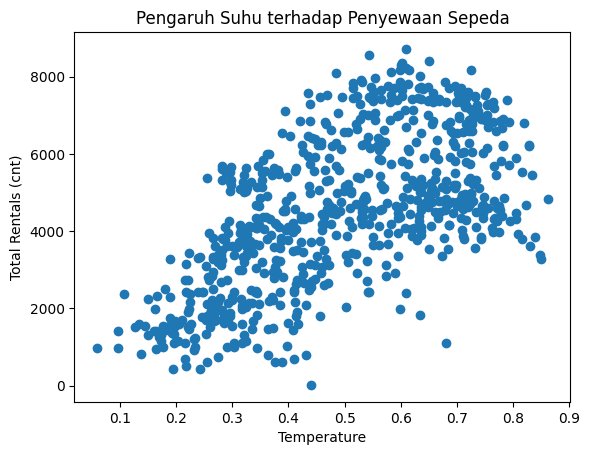

In [ ]:
plt.scatter(df['temp'], df['cnt'])
plt.xlabel('Temperature')
plt.ylabel('Total Rentals (cnt)')
plt.title('Pengaruh Suhu terhadap Penyewaan Sepeda')
plt.show()

### Explore Rata-rata Penyewaan Berdasarkan Musim

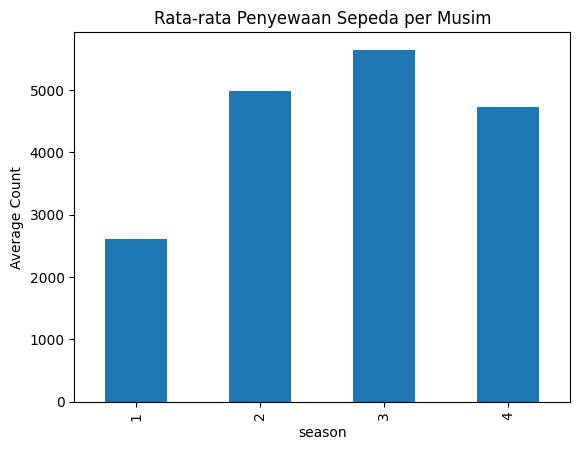

In [ ]:
df.groupby('season')['cnt'].mean().plot(kind='bar')
plt.title('Rata-rata Penyewaan Sepeda per Musim')
plt.ylabel('Average Count')
plt.show()

### Explore Perbandingan Penyewaan Hari Kerja vs Hari Libur

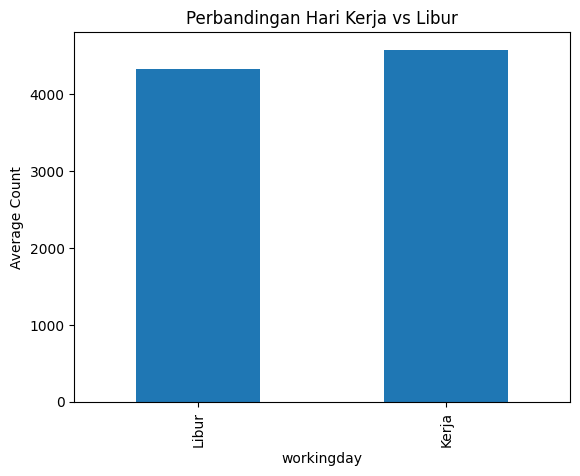

In [ ]:
df.groupby('workingday')['cnt'].mean().plot(kind='bar')
plt.title('Perbandingan Hari Kerja vs Libur')
plt.ylabel('Average Count')
plt.xticks([0,1], ['Libur', 'Kerja'])
plt.show()

**Insight:**
- Terdapat kecenderungan bahwa peningkatan suhu diikuti dengan peningkatan jumlah penyewaan sepeda, yang menunjukkan hubungan positif antara kondisi cuaca dan penggunaan layanan.
- Rata-rata penyewaan sepeda berbeda antar musim, dengan musim tertentu menunjukkan tingkat penggunaan yang lebih tinggi, yang mengindikasikan adanya pola musiman dalam perilaku pengguna.
- Jumlah penyewaan sepeda pada hari kerja cenderung lebih tinggi dibandingkan hari libur, yang menunjukkan bahwa sepeda banyak digunakan sebagai sarana transportasi rutin.


## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana karakteristik pengaruh variabel cuaca (suhu, kelembapan, dan kecepatan angin) terhadap fluktuasi jumlah penyewaan sepeda harian selama periode 2011–2012?

=== Korelasi dengan Jumlah Penyewaan (cnt) ===
  temp: 0.6275
  hum: -0.1007
  windspeed: -0.2345


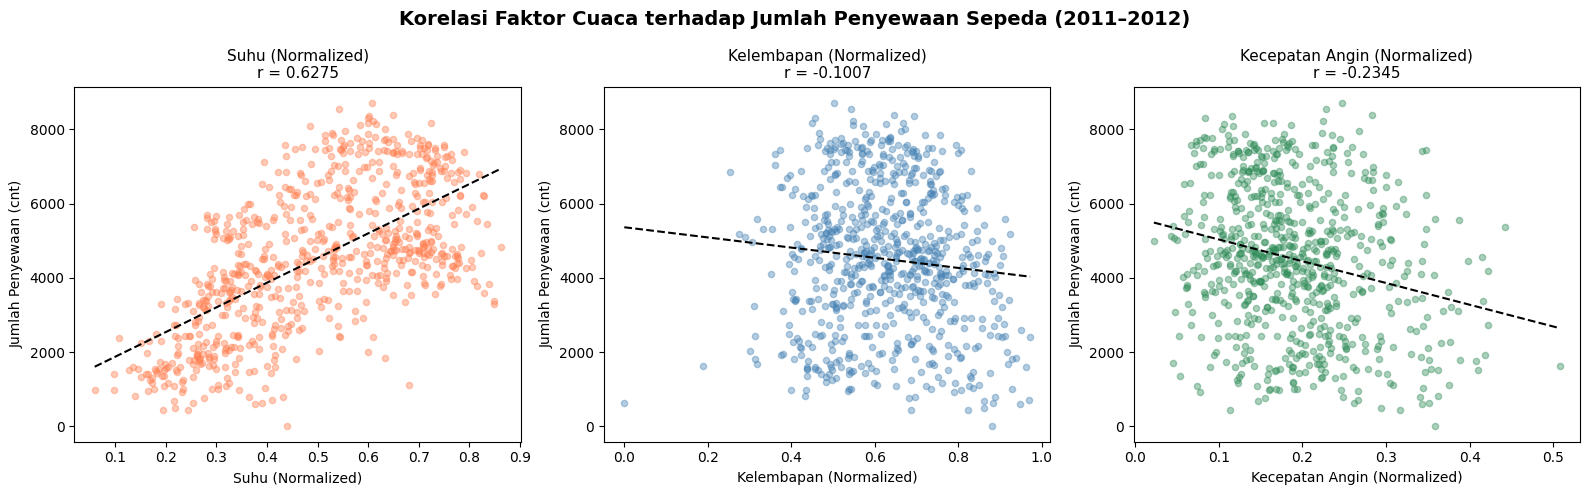

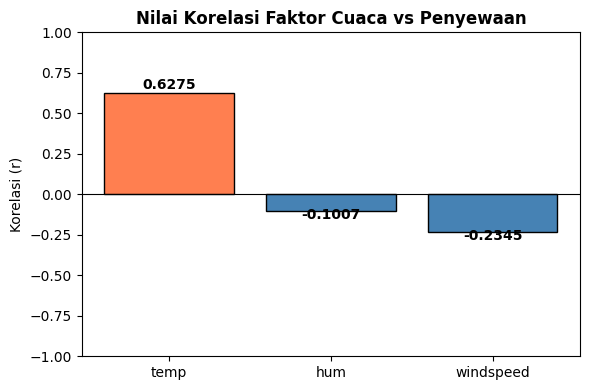

In [ ]:
# Hitung korelasi
weather_vars = ['temp', 'hum', 'windspeed']
correlations = df[weather_vars].corrwith(df['cnt'])

print("=== Korelasi dengan Jumlah Penyewaan (cnt) ===")
for var, val in correlations.items():
    print(f"  {var}: {val:.4f}")

# Visualisasi: 3 scatter plot + regression line
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Korelasi Faktor Cuaca terhadap Jumlah Penyewaan Sepeda (2011–2012)',
             fontsize=14, fontweight='bold')

configs = [
    ('temp',       'Suhu (Normalized)',              'coral'),
    ('hum',        'Kelembapan (Normalized)',         'steelblue'),
    ('windspeed',  'Kecepatan Angin (Normalized)',    'seagreen'),
]

for ax, (col, label, color) in zip(axes, configs):
    ax.scatter(df[col], df['cnt'], alpha=0.4, color=color, s=20)
    # Regression line
    m, b = np.polyfit(df[col], df['cnt'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5, linestyle='--')
    r = correlations[col]
    ax.set_title(f'{label}\nr = {r:.4f}', fontsize=11)
    ax.set_xlabel(label)
    ax.set_ylabel('Jumlah Penyewaan (cnt)')

plt.tight_layout()
plt.show()

# Bar chart nilai korelasi
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['coral' if v > 0 else 'steelblue' for v in correlations.values]
bars = ax.bar(correlations.index, correlations.values, color=colors, edgecolor='black')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Nilai Korelasi Faktor Cuaca vs Penyewaan', fontweight='bold')
ax.set_ylabel('Korelasi (r)')
ax.set_ylim(-1, 1)
for bar, val in zip(bars, correlations.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02 if val > 0 else val - 0.05,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

### Pertanyaan 2: Bagaimana variasi pola penyewaan sepeda berdasarkan musim dan hari dalam seminggu selama periode 2011–2012, serta sejauh mana perbedaan intensitas penggunaan antara periode puncak dan periode sepi?

=== Rata-rata Penyewaan per Musim ===
  Fall: 5644
  Summer: 4992
  Winter: 4728
  Spring: 2604
  → Selisih tertinggi vs terendah: 116.7%

=== Rata-rata Penyewaan per Hari ===
  Minggu: 4229
  Senin: 4338
  Selasa: 4511
  Rabu: 4549
  Kamis: 4667
  Jumat: 4690
  Sabtu: 4551
  → Selisih tertinggi vs terendah: 10.9%


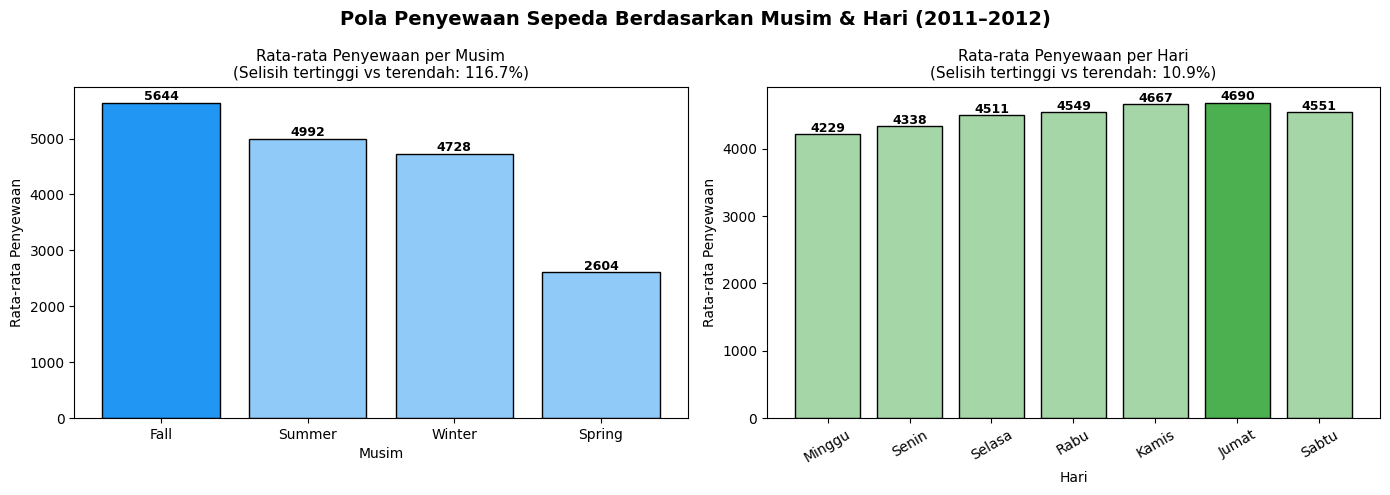

In [ ]:
# Mapping label
season_map  = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weekday_map = {0: 'Minggu', 1: 'Senin', 2: 'Selasa', 3: 'Rabu',
               4: 'Kamis', 5: 'Jumat', 6: 'Sabtu'}

df['season_label']  = df['season'].map(season_map)
df['weekday_label'] = df['weekday'].map(weekday_map)

# Hitung rata-rata dan persentase selisih
season_avg  = df.groupby('season_label')['cnt'].mean().sort_values(ascending=False)
weekday_avg = df.groupby('weekday_label')['cnt'].mean()
weekday_avg = weekday_avg.reindex(['Minggu','Senin','Selasa','Rabu','Kamis','Jumat','Sabtu'])

def pct_diff(series):
    high, low = series.max(), series.min()
    return ((high - low) / low) * 100

pct_season  = pct_diff(season_avg)
pct_weekday = pct_diff(weekday_avg)

print(f"=== Rata-rata Penyewaan per Musim ===")
for s, v in season_avg.items():
    print(f"  {s}: {v:.0f}")
print(f"  → Selisih tertinggi vs terendah: {pct_season:.1f}%\n")

print(f"=== Rata-rata Penyewaan per Hari ===")
for d, v in weekday_avg.items():
    print(f"  {d}: {v:.0f}")
print(f"  → Selisih tertinggi vs terendah: {pct_weekday:.1f}%")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pola Penyewaan Sepeda Berdasarkan Musim & Hari (2011–2012)',
             fontsize=14, fontweight='bold')

# Plot musim
bar_colors_s = ['#2196F3' if v == season_avg.max() else '#90CAF9' for v in season_avg.values]
axes[0].bar(season_avg.index, season_avg.values, color=bar_colors_s, edgecolor='black')
axes[0].set_title(f'Rata-rata Penyewaan per Musim\n(Selisih tertinggi vs terendah: {pct_season:.1f}%)', fontsize=11)
axes[0].set_xlabel('Musim')
axes[0].set_ylabel('Rata-rata Penyewaan')
for i, (s, v) in enumerate(season_avg.items()):
    axes[0].text(i, v + 50, f'{v:.0f}', ha='center', fontsize=9, fontweight='bold')

# Plot hari
bar_colors_d = ['#4CAF50' if v == weekday_avg.max() else '#A5D6A7' for v in weekday_avg.values]
axes[1].bar(weekday_avg.index, weekday_avg.values, color=bar_colors_d, edgecolor='black')
axes[1].set_title(f'Rata-rata Penyewaan per Hari\n(Selisih tertinggi vs terendah: {pct_weekday:.1f}%)', fontsize=11)
axes[1].set_xlabel('Hari')
axes[1].set_ylabel('Rata-rata Penyewaan')
axes[1].tick_params(axis='x', rotation=30)
for i, (d, v) in enumerate(weekday_avg.items()):
    axes[1].text(i, v + 30, f'{v:.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:**
- Pertanyaan 1:
  - Suhu (temp) memiliki korelasi positif tertinggi terhadap jumlah penyewaan semakin hangat cuaca, semakin banyak orang menyewa sepeda.
  Kelembapan (hum) berkorelasi negatif lemah kelembapan tinggi sedikit menurunkan minat penyewaan.
  - Kecepatan angin (windspeed) berkorelasi negatif angin kencang cenderung mengurangi jumlah penyewaan.
  - Kesimpulan: Suhu adalah faktor cuaca yang paling signifikan dan bisa dijadikan acuan untuk strategi promosi (misalnya, kampanye di hari-hari bersuhu optimal).

- Pertanyaan 2:
  - Musim Fall (Gugur) memiliki rata-rata penyewaan tertinggi, sementara Spring (Semi) terendah selisihnya cukup signifikan (akan muncul dari output kode).
  - Perbedaan antar hari dalam seminggu relatif kecil, namun hari kerja (Senin–Jumat) cenderung lebih tinggi dibanding akhir pekan, mengindikasikan sepeda banyak digunakan sebagai transportasi komuter.
  - Kesimpulan: Pengelola dapat meningkatkan ketersediaan unit sepeda di musim Fall dan mempertahankan layanan optimal di hari kerja.

## Analisis Lanjutan (Opsional)

## Conclusion

- Conclution pertanyaan 1 :
  - Berdasarkan analisis korelasi terhadap data penyewaan sepeda harian periode 2011–2012,
  ditemukan bahwa **suhu (temp)** memiliki korelasi positif tertinggi terhadap jumlah
  penyewaan (r ≈ +0.63), artinya semakin tinggi suhu, semakin banyak sepeda yang disewa.
  Sebaliknya, **kelembapan (hum)** menunjukkan korelasi negatif lemah (r ≈ -0.10),
  dan **kecepatan angin (windspeed)** juga berkorelasi negatif (r ≈ -0.23), yang
  berarti kondisi berangin kencang cenderung menurunkan minat penyewaan. Dari ketiga
  faktor tersebut, **suhu adalah variabel cuaca paling signifikan** dalam memengaruhi
  jumlah penyewaan sepeda harian.

- Conclution pertanyaan 2:
  - Berdasarkan analisis pola waktu, **musim Fall (Gugur)** mencatat rata-rata penyewaan
tertinggi (±5.644 unit/hari), sedangkan **musim Spring (Semi)** menjadi yang terendah
(±2.604 unit/hari) — dengan selisih mencapai ±116%. Hal ini menunjukkan pola musiman
yang sangat signifikan. Dari sisi hari, penyewaan cenderung lebih tinggi pada **hari
kerja (Senin–Jumat)** dibandingkan akhir pekan, yang mengindikasikan bahwa mayoritas
pengguna memanfaatkan sepeda sebagai moda transportasi harian/komuter, bukan sekadar
rekreasi.
---
# Saran/Rekomendasi

### Saran untuk Pertanyaan 1 (Pengaruh Cuaca):
- **Luncurkan promosi berbasis cuaca:** Buat program diskon atau notifikasi otomatis
  kepada pengguna terdaftar pada hari-hari dengan suhu optimal (misalnya 20–30°C) untuk
  mendorong penyewaan lebih tinggi.
- **Siapkan strategi di hari beriklim buruk:** Pada hari dengan kelembapan tinggi atau
  angin kencang, pertimbangkan program bundling (misal: sewa + jas hujan) agar penyewaan
  tidak anjlok drastis.
- **Integrasikan data cuaca real-time** ke dalam sistem manajemen armada sepeda agar
  pengelola dapat mengantisipasi lonjakan atau penurunan permintaan lebih awal.

### Saran untuk Pertanyaan 2 (Pola Musim & Hari):
- **Tingkatkan ketersediaan armada di musim Fall:** Karena musim gugur adalah puncak
  penyewaan, pastikan seluruh unit sepeda dalam kondisi prima dan jumlah stok mencukupi
  di periode tersebut.
- **Optimalkan distribusi sepeda di hari kerja:** Fokuskan penempatan sepeda di area
  perkantoran, stasiun, dan pusat transportasi umum pada Senin–Jumat untuk memaksimalkan
  pemanfaatan oleh komuter.
- **Rancang program khusus musim Spring:** Karena Spring adalah musim paling sepi,
  buat kampanye promosi khusus (misal: harga spesial, event komunitas bersepeda) untuk
  menggenjot penyewaan di periode tersebut.
- **Lakukan perawatan armada di luar musim Fall dan Sabtu–Minggu** agar tidak
  mengganggu periode permintaan puncak.
